In [22]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from sklearn.metrics import average_precision_score

# =========================
# 0) 固定参数
# =========================
FOLD_DIR   = "./best_xgb_5fold_saved"
N_FOLDS    = 5

K_RATIO    = 0.05
A_WEIGHT   = 10.0
EPSILON    = 1e-3

GRID_SIZE  = 60          # 你要均匀网格，建议 40/60 更细
MIN_IN_SAMPLES = 1      # 与搜索脚本一致（如果你想放宽可改 5，但 best 会飘）
LABEL_DIFF_MODE = "jaccard"
K_SWD_CAP = 300

SAVE_FIG = True
OUT_FIG1 = f"AD_surface_count_UNIFORM_a10_eps1e-3_k0.05zz.png"
OUT_FIG2 = f"AD_surface_AUPRCin_UNIFORM_a10_eps1e-3_k0.05zz.png"
OUT_CSV  = f"AD_grid_stats_UNIFORM_a10_eps1e-3_k0.05zz.csv"

# =========================
# 1) 工具函数
# =========================
def l2_normalize(X, eps=1e-12):
    X = X.astype(np.float32, copy=False)
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (n + eps)

def cosine_sim_query(Xq_n, Xtr_n):
    return np.clip(Xq_n @ Xtr_n.T, 0.0, 1.0).astype(np.float32)

def compute_weights(sim_vals, a, epsilon):
    s = np.clip(sim_vals, epsilon, 1.0)
    return np.exp(-a * (1.0 - s) / s).astype(np.float32)

def pairwise_label_diff_scalar(y_t, y_nei, mode="jaccard", eps=1e-12):
    y_t = y_t.astype(np.int8, copy=False)
    y_nei = y_nei.astype(np.int8, copy=False)
    if mode == "hamming":
        return np.mean(np.abs(y_nei - y_t[None, :]), axis=1).astype(np.float32)
    if mode == "jaccard":
        inter = np.sum((y_nei == 1) & (y_t[None, :] == 1), axis=1).astype(np.float32)
        union = np.sum((y_nei == 1) | (y_t[None, :] == 1), axis=1).astype(np.float32)
        j = inter / (union + eps)
        return (1.0 - j).astype(np.float32)
    raise ValueError("LABEL_DIFF_MODE must be 'jaccard' or 'hamming'")

# =========================
# 2) AUPRC：baseline 填充
# =========================
def per_label_ap(y_true, y_prob):
    y_true = np.asarray(y_true).astype(np.int8)
    y_prob = np.asarray(y_prob).astype(np.float32)
    L = y_true.shape[1]
    ap = np.full(L, np.nan, dtype=float)
    for j in range(L):
        yt = y_true[:, j]
        if len(np.unique(yt)) < 2:
            continue
        ap[j] = average_precision_score(yt, y_prob[:, j])
    return ap

def macro_auprc_with_baseline_fill(y_true_in, y_prob_in, ap_baseline, label_idx):
    ap_in = per_label_ap(y_true_in, y_prob_in)
    ap_filled = ap_in.copy()
    nan_mask = np.isnan(ap_filled)
    ap_filled[nan_mask] = ap_baseline[nan_mask]
    return float(np.mean(ap_filled[label_idx]))

# =========================
# 3) 读取 fold npz
# =========================
def load_fold_npz(fold_id: int):
    path = os.path.join(FOLD_DIR, f"fold_{fold_id:02d}.npz")
    z = np.load(path, allow_pickle=True)
    return z["X_tr"], z["y_tr"], z["X_va"], z["y_va"], z["y_prob_va"]

# =========================
# 4) SWD / rho / IA（搜索脚本同款 SWD）
# =========================
def compute_SWD_topk(Xtr, ytr, k_swd_eff, a, eps):
    Xn = l2_normalize(Xtr)
    sim = cosine_sim_query(Xn, Xn)  # (N,N) 训练-训练相似度

    N = ytr.shape[0]
    SWD = np.zeros(N, dtype=np.float32)
    k_eff = max(1, min(k_swd_eff, N - 1))

    for t in range(N):
        sims_t = sim[t]
        idxs = np.argpartition(sims_t, -(k_eff + 1))[-(k_eff + 1):]
        idxs = idxs[idxs != t]
        if idxs.size == 0:
            continue
        sv = sims_t[idxs]
        w  = compute_weights(sv, a, eps)
        diffs = pairwise_label_diff_scalar(ytr[t], ytr[idxs], mode=LABEL_DIFF_MODE)
        SWD[t] = float((w * sv * diffs).sum() / (w.sum() + eps))
    return SWD, Xn

def compute_rho_IA_given_SWD(Xtr_n, SWD, Xva, k_eff, a, eps):
    Xva_n = l2_normalize(Xva)
    sim_qt = cosine_sim_query(Xva_n, Xtr_n)  # (M,N)
    M = Xva.shape[0]
    rho = np.zeros(M, dtype=np.float32)
    IA  = np.zeros(M, dtype=np.float32)
    for i in range(M):
        sims = sim_qt[i]
        idxk = np.argpartition(sims, -k_eff)[-k_eff:]
        sk = sims[idxk]
        w  = compute_weights(sk, a, eps)
        rho[i] = float(w.mean())
        IA[i]  = float((w * SWD[idxk]).sum() / (w.sum() + eps))
    return rho, IA



In [23]:

print(f"[INFO] UNIFORM grid: a={A_WEIGHT}, eps={EPSILON}, k_ratio={K_RATIO}, grid={GRID_SIZE}, MIN_IN={MIN_IN_SAMPLES}")

folds = []
for f in range(1, N_FOLDS + 1):
    X_tr, y_tr, X_va, y_va, y_prob_va = load_fold_npz(f)
    folds.append((X_tr, y_tr, X_va, y_va, y_prob_va))

fold_cache = []  # (rho, IA, y_va, y_prob_va)
all_rho, all_IA = [], []

# ---- 5.1 逐折计算 SWD(用0.1N cap300) + rho/IA(用k_ratio*N) ----
for fold_id, (X_tr, y_tr, X_va, y_va, y_prob_va) in enumerate(folds, start=1):
    Ntr = X_tr.shape[0]
    k_swd_eff = min(max(int(0.1 * Ntr), 1), K_SWD_CAP)  # 关键：与搜索脚本一致
    k_eff = max(int(float(K_RATIO) * Ntr), 1)
    k_eff = min(k_eff, Ntr)

    print(f"[INFO] fold {fold_id}: Ntr={Ntr}, k_eff={k_eff}, k_swd_eff={k_swd_eff}")

    SWD, Xtr_n = compute_SWD_topk(X_tr, y_tr, k_swd_eff, A_WEIGHT, EPSILON)
    rho_s, IA  = compute_rho_IA_given_SWD(Xtr_n, SWD, X_va, k_eff, A_WEIGHT, EPSILON)

    fold_cache.append((rho_s, IA, y_va, y_prob_va))
    all_rho.append(rho_s); all_IA.append(IA)

all_rho = np.concatenate(all_rho)
all_IA  = np.concatenate(all_IA)

# ---- 5.2 baseline & label_idx（跨所有fold验证集）----
Y_all = np.concatenate([fc[2] for fc in fold_cache], axis=0)
P_all = np.concatenate([fc[3] for fc in fold_cache], axis=0)
ap_baseline = per_label_ap(Y_all, P_all)
label_idx = np.array([j for j in range(Y_all.shape[1]) if not np.isnan(ap_baseline[j])], dtype=int)
print(f"[INFO] global evaluable labels: {len(label_idx)}/{Y_all.shape[1]}")

# ---- 5.3 均匀网格（linspace）----
rho_cuts = np.linspace(all_rho.min(), all_rho.max(), GRID_SIZE)
IA_cuts  = np.linspace(all_IA.min(),  all_IA.max(),  GRID_SIZE)
X_mesh, Y_mesh = np.meshgrid(rho_cuts, IA_cuts)

# ---- 5.4 surface：mean_n / mean_cov / mean_ap_in（画图用）----
mean_n   = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float64)
mean_cov = np.zeros_like(mean_n)
mean_ap_in = np.full_like(mean_n, np.nan, dtype=np.float64)

# ---- 5.5 搜索同款 best：只对满足 MIN_IN 的 fold 求平均 ----
best_ap = -np.inf
best_cov = np.nan
best_rho_th = np.nan
best_ia_th  = np.nan

for i, ia_th in enumerate(IA_cuts):
    for j, rho_th in enumerate(rho_cuts):
        cnt_list = []
        cov_list = []
        ap_list  = []

        s_ap = 0.0
        cnt_fold = 0
        cov_sum = 0.0

        for (rho_s, IA, y_va, y_prob_va) in fold_cache:
            in_m = (rho_s >= rho_th) & (IA <= ia_th)
            n_in = int(in_m.sum())

            cnt_list.append(n_in)
            cov_list.append(n_in / len(rho_s))

            if n_in >= MIN_IN_SAMPLES:
                ap_in = macro_auprc_with_baseline_fill(
                    y_va[in_m], y_prob_va[in_m],
                    ap_baseline, label_idx
                )
                ap_list.append(ap_in)

                s_ap += ap_in
                cnt_fold += 1
                cov_sum += n_in / len(rho_s)
            else:
                ap_list.append(np.nan)

        mean_n[i, j] = float(np.mean(cnt_list))
        mean_cov[i, j] = float(np.mean(cov_list))
        mean_ap_in[i, j] = float(np.nanmean(ap_list)) if np.any(np.isfinite(ap_list)) else np.nan

        if cnt_fold > 0:
            mean_ap_search = s_ap / cnt_fold
            mean_cov_search = cov_sum / cnt_fold
            if mean_ap_search > best_ap:
                best_ap = mean_ap_search
                best_cov = mean_cov_search
                best_rho_th = float(rho_th)
                best_ia_th  = float(ia_th)

if not np.isfinite(best_ap):
    best_ap = np.nan

# best 点对应 surface 的 n/cov（用于标注）
j_best = int(np.argmin(np.abs(rho_cuts - best_rho_th)))
i_best = int(np.argmin(np.abs(IA_cuts  - best_ia_th)))
n_best = mean_n[i_best, j_best]
cov_best_surface = mean_cov[i_best, j_best]

print(f"[BEST-UNIFORM] rho_th={best_rho_th:.6g}, IA_th={best_ia_th:.6g}, AUPRC_in={best_ap:.4f}, cov={best_cov:.3f} | (surface n≈{int(round(n_best))}, cov≈{cov_best_surface:.3f})")

# ---- 5.6 导出 CSV ----
records = []
for i, ia_th in enumerate(IA_cuts):
    for j, rho_th in enumerate(rho_cuts):
        records.append({
            "rho_th": float(rho_th),
            "IA_th":  float(ia_th),
            "count_in_mean": float(mean_n[i, j]),
            "coverage_in_mean": float(mean_cov[i, j]),
            "AUPRC_in_mean_surface": float(mean_ap_in[i, j]) if np.isfinite(mean_ap_in[i, j]) else np.nan,
            "GRID_SIZE": int(GRID_SIZE),
            "MIN_IN_SAMPLES": int(MIN_IN_SAMPLES),
            "a": float(A_WEIGHT),
            "eps": float(EPSILON),
            "k_ratio": float(K_RATIO),
            "label_diff_mode": LABEL_DIFF_MODE,
        })
pd.DataFrame(records).to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print("[SAVED]", OUT_CSV)


[INFO] UNIFORM grid: a=10.0, eps=0.001, k_ratio=0.05, grid=60, MIN_IN=1
[INFO] fold 1: Ntr=3961, k_eff=198, k_swd_eff=300
[INFO] fold 2: Ntr=3961, k_eff=198, k_swd_eff=300
[INFO] fold 3: Ntr=3962, k_eff=198, k_swd_eff=300
[INFO] fold 4: Ntr=3962, k_eff=198, k_swd_eff=300
[INFO] fold 5: Ntr=3962, k_eff=198, k_swd_eff=300
[INFO] global evaluable labels: 138/138
[BEST-UNIFORM] rho_th=0.00852133, IA_th=0.582436, AUPRC_in=0.4620, cov=0.110 | (surface n≈109, cov≈0.110)
[SAVED] AD_grid_stats_UNIFORM_a10_eps1e-3_k0.05zz.csv


/tmp/ipykernel_2897/4003372405.py:77: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[SAVED] AD_surface_count_UNIFORM_a10_eps1e-3_k0.05zz.png


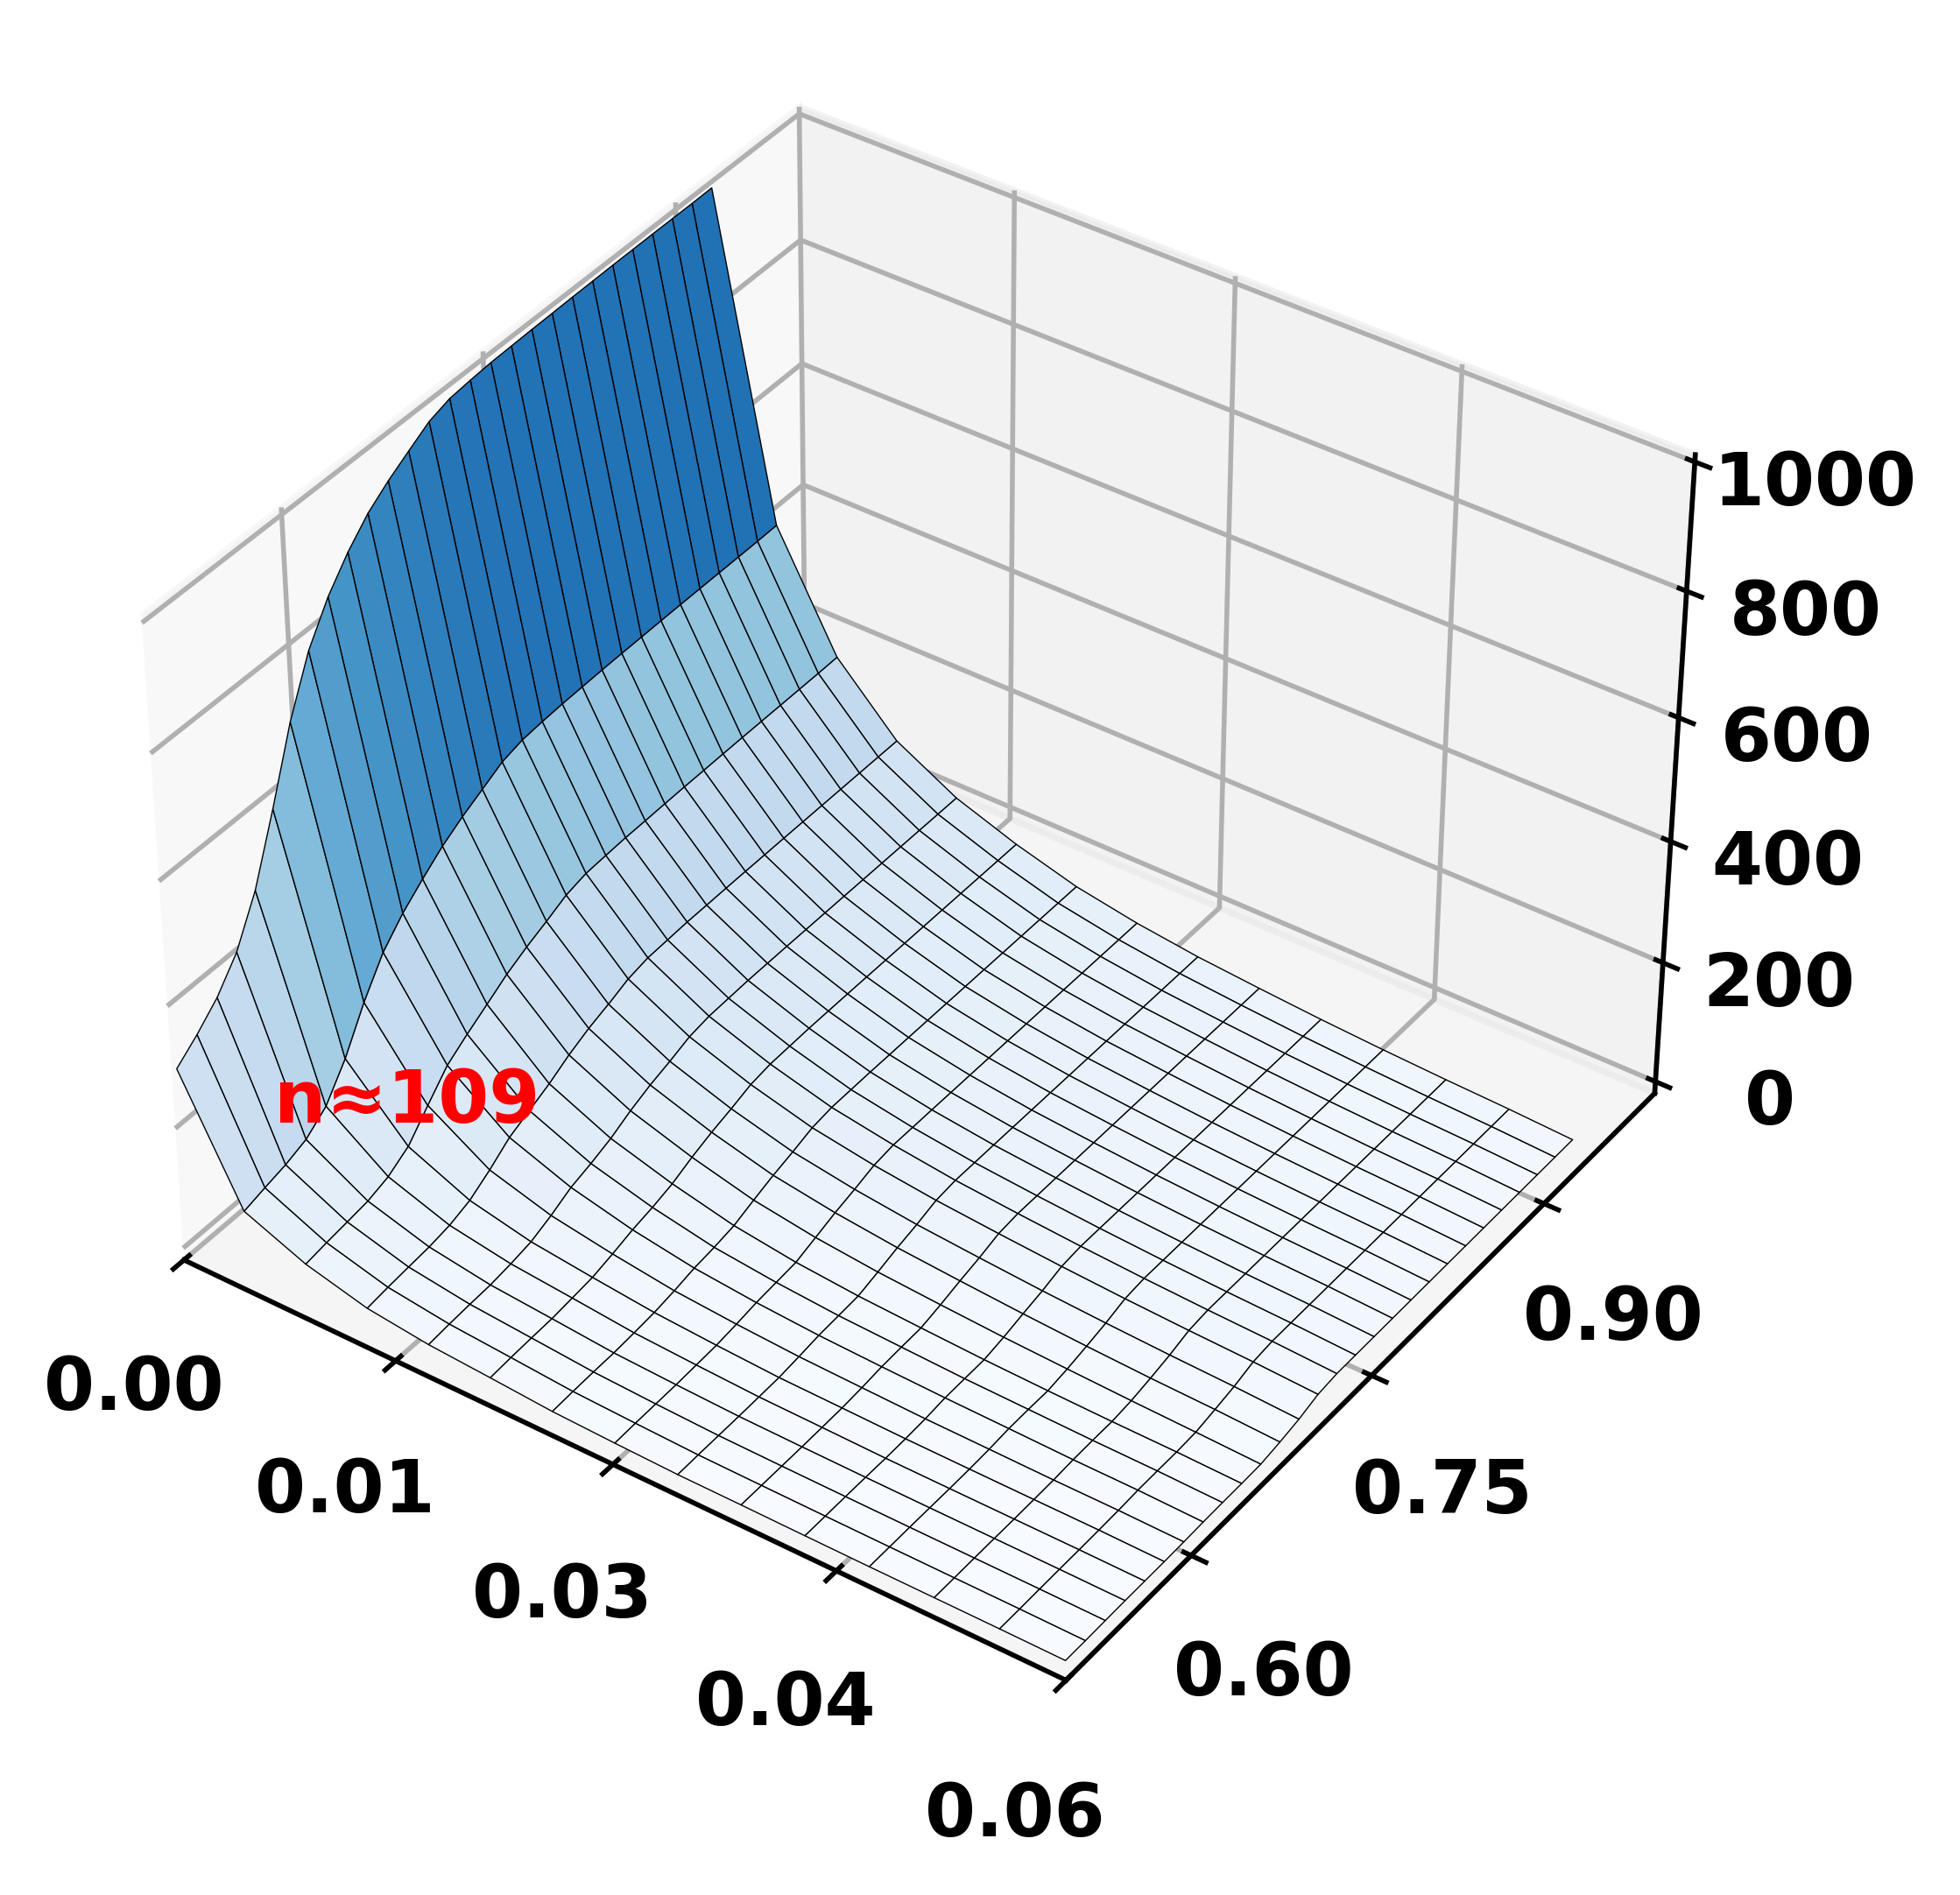

In [24]:

# =========================
# 6) 绘图前：裁剪 x/y 范围（只显示这段范围内的网格）
# =========================
# 你想规定的 x/y 轴范围（按需要改）
X_LIM = (0.0, 0.06)   # rho_th 范围示例：自己调整
Y_LIM = (0.50, 1.00)  # IA_th  范围示例：自己调整

# X_mesh / Y_mesh 来自 meshgrid(rho_cuts, IA_cuts)
rho_cuts = X_mesh[0, :]      # (GRID_SIZE,)
ia_cuts  = Y_mesh[:, 0]      # (GRID_SIZE,)

j_mask = (rho_cuts >= X_LIM[0]) & (rho_cuts <= X_LIM[1])
i_mask = (ia_cuts  >= Y_LIM[0]) & (ia_cuts  <= Y_LIM[1])

# 裁剪后的网格和Z
Xc = X_mesh[np.ix_(i_mask, j_mask)]
Yc = Y_mesh[np.ix_(i_mask, j_mask)]
mean_n_c = mean_n[np.ix_(i_mask, j_mask)]
mean_ap_in_c = mean_ap_in[np.ix_(i_mask, j_mask)]

# best 点也要判断是否在显示范围内（不在就不画星）
best_in_view = (X_LIM[0] <= best_rho_th <= X_LIM[1]) and (Y_LIM[0] <= best_ia_th <= Y_LIM[1])

# =========================
# 6) 绘图 1：count surface（标 best 点）
# =========================
fig1 = plt.figure(figsize=(6, 5), dpi=500)
ax1 = fig1.add_subplot(1, 1, 1, projection='3d')

ax1.plot_surface(
    Xc, Yc, mean_n_c,
    cmap='Blues',
    edgecolor='k', linewidth=0.2, antialiased=True,
    vmin=0, vmax=np.nanmax(mean_n_c)
)

# 规定 x/y 轴显示范围（关键）
ax1.set_xlim(X_LIM)
ax1.set_ylim(Y_LIM)

ax1.tick_params(axis='both', labelsize=12, width=1.5)
for tck in ax1.get_xticklabels() + ax1.get_yticklabels() + ax1.get_zticklabels():
    tck.set_fontweight('bold')
ax1.view_init(elev=45, azim=-45)
from matplotlib.ticker import MaxNLocator, FormatStrFormatter


# --- 1) 减少刻度数量（关键）---
ax1.xaxis.set_major_locator(MaxNLocator(5))  # x轴最多5个刻度
ax1.yaxis.set_major_locator(MaxNLocator(4))  # y轴最多5个刻度
ax1.zaxis.set_major_locator(MaxNLocator(5))  # z轴可选

# --- 2) 统一格式（避免长数字挤）---
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# z轴如果是整数可用 '%.0f'，否则也用 '%.2f'
# ax1.zaxis.set_major_formatter(FormatStrFormatter('%.0f'))



# --- 4) 稍微调整视角也能明显改善（可选）---
ax1.view_init(elev=38, azim=-55)


if best_in_view:
    # 用裁剪后的 Z 最大值来决定标注高度
    n_best_local = float(mean_n_c.max()) if np.isfinite(mean_n_c).any() else 0.0
    z_high = n_best + (np.nanmax(mean_n_c) * 0.03)

    txt = ax1.text(
        best_rho_th, best_ia_th, z_high + (np.nanmax(mean_n_c) * 0.01),
        f"n≈{int(round(n_best))}",
        color='red', fontsize=12, fontweight='bold',
        ha='center', zorder=11
    )

plt.tight_layout()
if SAVE_FIG:
    fig1.savefig(OUT_FIG1, bbox_inches="tight")
    print("[SAVED]", OUT_FIG1)
plt.show()



/tmp/ipykernel_2897/2196995666.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[SAVED] AD_surface_AUPRCin_UNIFORM_a10_eps1e-3_k0.05zz.png


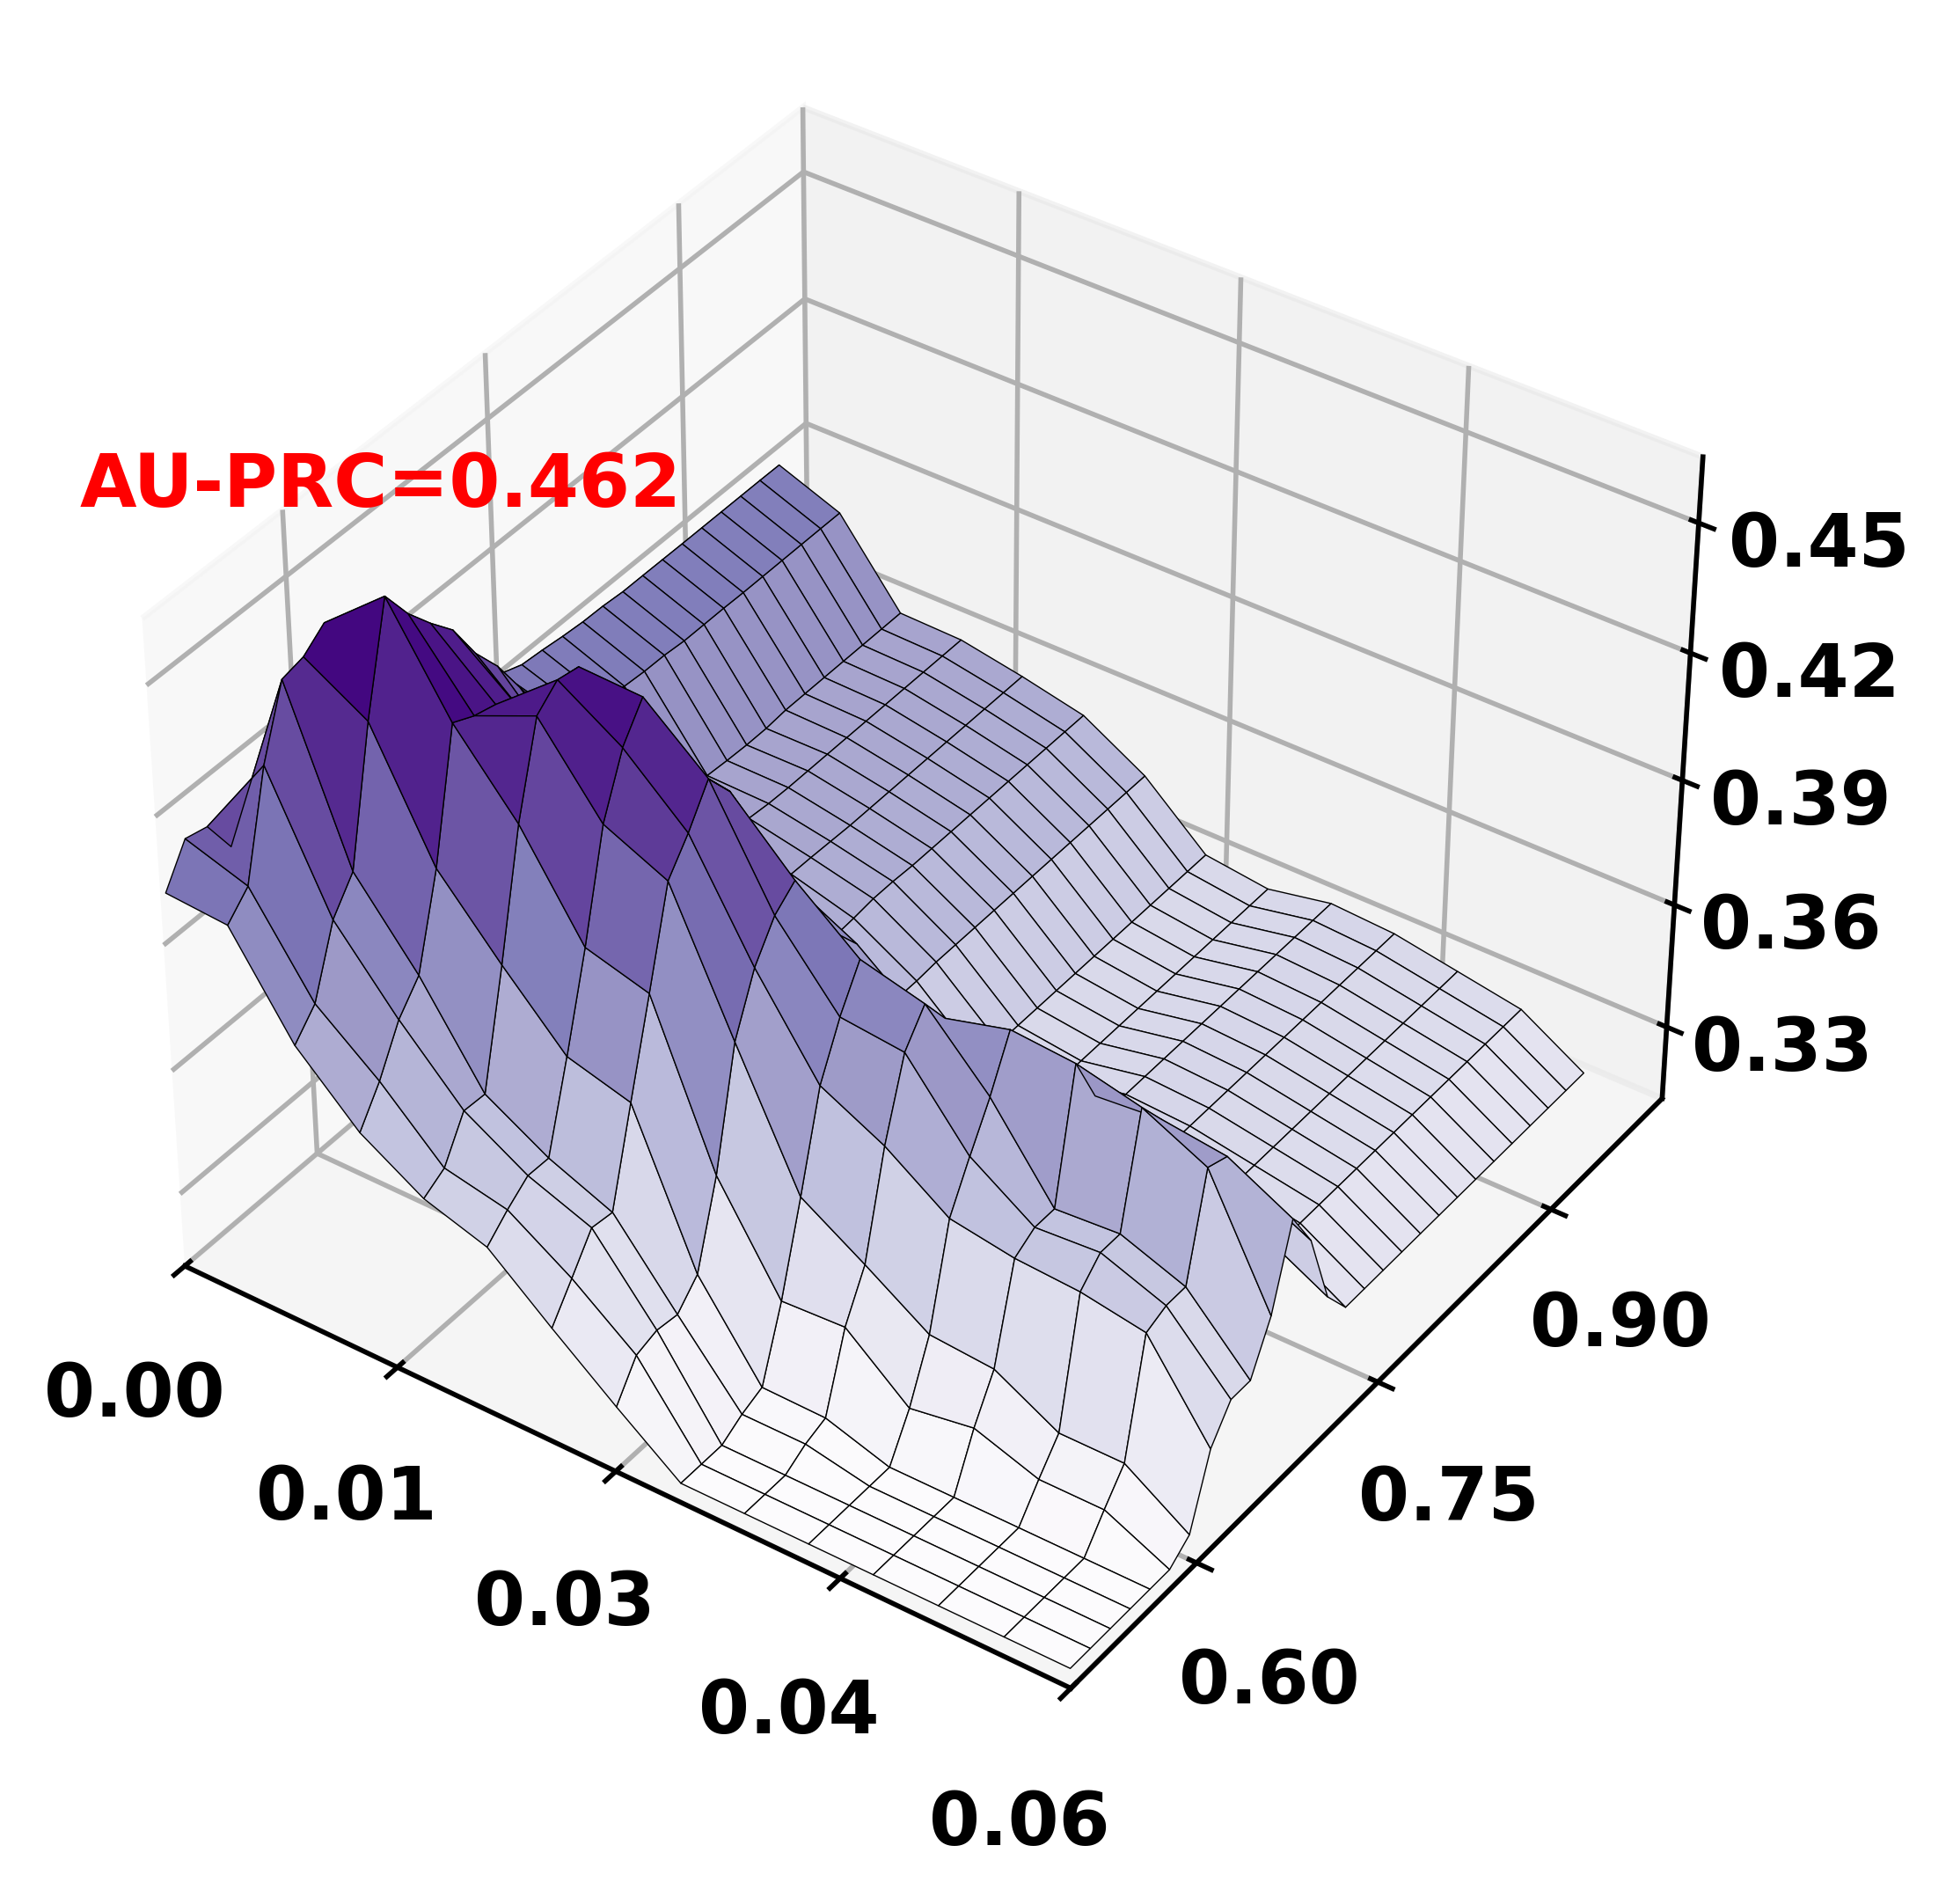

In [25]:
# =========================
# 7) 绘图 2：AUPRC_in surface（标 best 点）
# =========================
fig2 = plt.figure(figsize=(6, 5), dpi=500)
ax2 = fig2.add_subplot(1, 1, 1, projection='3d')

Z_in_c = np.ma.masked_invalid(mean_ap_in_c)
ax2.plot_surface(
    Xc, Yc, Z_in_c,
    cmap='Purples',
    edgecolor='k', linewidth=0.2, antialiased=True
)

# 规定 x/y 轴显示范围（关键）
ax2.set_xlim(X_LIM)
ax2.set_ylim(Y_LIM)

ax2.tick_params(axis='both', labelsize=12, width=1.5)
for tck in ax2.get_xticklabels() + ax2.get_yticklabels() + ax2.get_zticklabels():
    tck.set_fontweight('bold')
ax2.view_init(elev=45, azim=-45)

# --- 1) 减少刻度数量（关键）---
ax2.xaxis.set_major_locator(MaxNLocator(5))  # x轴最多5个刻度
ax2.yaxis.set_major_locator(MaxNLocator(4))  # y轴最多5个刻度
ax2.zaxis.set_major_locator(MaxNLocator(5))  # z轴可选

# --- 2) 统一格式（避免长数字挤）---
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# z轴如果是整数可用 '%.0f'，否则也用 '%.2f'
# ax1.zaxis.set_major_formatter(FormatStrFormatter('%.0f'))



# --- 4) 稍微调整视角也能明显改善（可选）---
ax2.view_init(elev=38, azim=-55)




if best_in_view:
    highlight_z = (mean_ap_in[i_best, j_best] if np.isfinite(mean_ap_in[i_best, j_best]) else best_ap) + 0.01

    txt2 = ax2.text(
        best_rho_th, best_ia_th, highlight_z + 0.01,
        f"AU-PRC={best_ap:.3f}",
        color='red', fontsize=12, fontweight='bold',
        ha='center', zorder=11
    )

plt.tight_layout()
if SAVE_FIG:
    fig2.savefig(OUT_FIG2, bbox_inches="tight")
    print("[SAVED]", OUT_FIG2)
plt.show()
